# ___Power Analysis___
---------------------------

In [2]:
!python --version

Python 3.14.2


The system cannot find the path specified.


In [47]:
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
from scipy import stats
from numba import njit

## ___Examples___
----------------------

In [ ]:
# https://www.djmannion.net/psych_programming/data/power/power.html
# https://docs.scipy.org/doc/scipy-1.16.2/reference/generated/scipy.stats.power.html
# https://statsthinking21.github.io/statsthinking21-python/09-StatisticalPower.html

### __`statsmodels`__

In [36]:
# power for an independent t test - determine the significance of differences in the means of two groups
sm.stats.TTestIndPower().solve_power(effect_size=0.5, power=0.8, alpha=0.05) # this gives the needed sample size

#------------------
# EFFECT SIZES
#------------------
# Cohen classified effect sizes as small (d = 0.2), medium (d = 0.5), and large (d ≥ 0.8). 5. 
# according to Cohen, “a medium effect of . 5 is visible to the naked eye of a careful observer.
# https://pmc.ncbi.nlm.nih.gov/articles/PMC3444174/

63.765610587854006

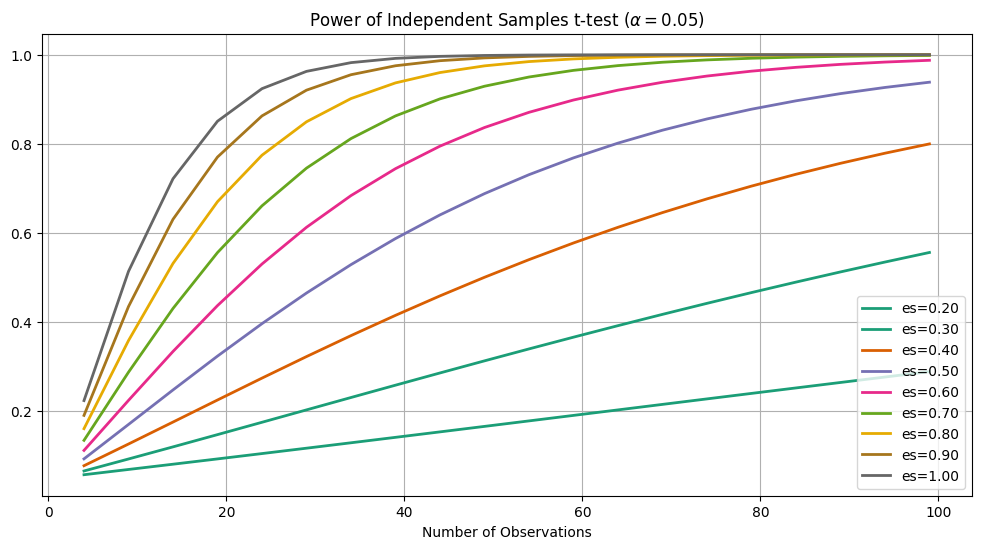

In [40]:
# plot a power curve (independent t test)

effect_sizes = np.linspace(start=0.2, stop=1.0, num=9)
sample_sizes = np.arange(start=4, stop=100, step=5)

fig, axes = plt.subplots()
fig.set_size_inches(12, 6)
sm.stats.TTestIndPower().plot_power(ax=axes, effect_size=effect_sizes, alpha=0.05, nobs=sample_sizes, dep_var="nobs", title=r"Power of Independent Samples t-test ($\alpha = 0.05$)")
axes.grid()
axes.set_axisbelow(True)
plt.show()

In [39]:
# power for a paired t test - determine the significance of differences in the means of two groups
sm.stats.TTestPower().solve_power(effect_size=0.5, power=0.8, alpha=0.05) # this gives the needed sample size

33.36713118431779

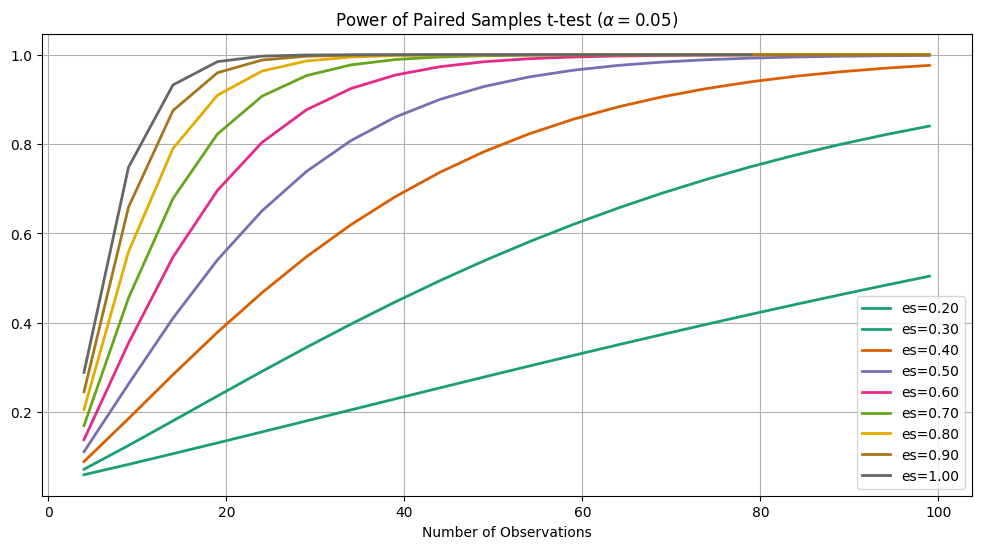

In [41]:
# plot a power curve (dependent t test)

effect_sizes = np.linspace(start=0.2, stop=1.0, num=9)
sample_sizes = np.arange(start=4, stop=100, step=5)

fig, axes = plt.subplots()
fig.set_size_inches(12, 6)
sm.stats.TTestPower().plot_power(ax=axes, effect_size=effect_sizes, alpha=0.05, nobs=sample_sizes, dep_var="nobs", title=r"Power of Paired Samples t-test ($\alpha = 0.05$)")
axes.grid()
axes.set_axisbelow(True)
plt.show()

### __`scipy`__

In [46]:
# using scipy, we can put the sample estimates of statsmodels to test

# let's look at the paired t test sample size, for a medium effect size (d = 0.5), alpha = 0.05 and a power of 80%
ssize = np.ceil(sm.stats.TTestPower().solve_power(effect_size=0.5, alpha=0.05, power=0.8)).astype(int)
ssize

np.int64(34)

In [75]:
# simulate two samples with size 34

def _power_run_paired_ttest(niterations: int, sample_size: int, effect_size: float) -> NDArray[np.float64]:
    
    """
    runs a repeated paired t test calculations and returns the p values of those calculations.
    niterations: int - number of times to repeat the paired t test calculations.
    sample_size: int - sample size for the randomly generated samples.
    effect_size: float - expected effect szie.
    """
   
    # we use ttest_rel here because our samples are related (have shared members) and we collect the p values across all iterations in an array and return it
    return np.array([stats.ttest_rel(a=np.random.normal(loc=0, scale=1, size=sample_size),
                                     b=np.random.normal(loc=effect_size, scale=1, size=sample_size)).pvalue for _ in range(niterations)], dtype=np.float64)
    # we could take the first input out of the loop to improve performance, but this can lead to biased results since one array gets compared to all the other repeatedly generated
    # arrays, so if the first one is biased, that extends to all our iterations ....... yikes!

In [102]:
pvals = _power_run_paired_ttest(niterations=1000, sample_size=ssize, effect_size=0.8)
# on average (across all the iterations), the probability of our p value being significant (<0.05) is this result
# and if this is greater than our power of 0.8, we're good :)
(pvals < 0.05).mean() 

np.float64(0.883)

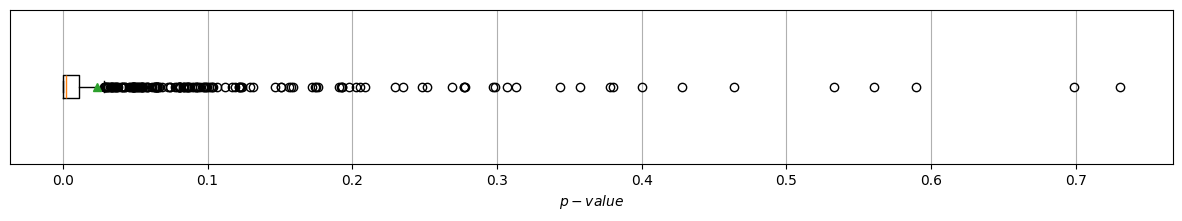

In [118]:
fig, axes = plt.subplots()
fig.set_size_inches(15, 2)
axes.boxplot(pvals, orientation="horizontal", showmeans=True)
axes.grid()
axes.set_xlabel(r"$p-value$")
axes.set_yticks([])
plt.show()

## ___Hypotheses___
---------------------

In [ ]:
# chapter 3 hypotheses

# Sympatric host ecotype – AM fungal community pairs will demonstrate superior adaptive fitness 
# (measured by total plant biomass, plant height, PRLC & total length of hyphae in gram soil) compared to their allopatric counterparts

# The extent of outsourcing reflected in the fine absorptive root traits will be the highest for each plant ecotype when paired with 
# sympatric AM fungal community compared to pairings with foreign AM fungal communities.

# Amongst the sympatric AM fungal-host ecotype pairs, the magnitude of this influence will be more pronounced where the hosts needed the
# AM fungi more (e.g. low phosphorus soils).

# The fine absorptive root traits (collaboration gradient) will also be influenced by the AM fungal community composition in the soil
# samples, but this influence will be less pronounced compared to the provenance specific coadaptations.

In [33]:
#-----------------------------------------------------------------------------------------------------------------------------------------------
# SINCE OUR ALLOPATRIC AND SYMPATRIC HOST & SYMBIONTS PAIRS WILL HAVE SHARED MEMBERS, WE CANNOT ASSUME THAT OUR TWO SAMPLES ARE INDEPENDENT
# WHAT WE NEED IS A DEPENDENT (PAIRED) t TEST
#-----------------------------------------------------------------------------------------------------------------------------------------------

In [2]:
# first what statistical test will be best to analyze our data???

# hypo 1 - two sample t test
# hypo 2 - same, two sample t test

# BUT OUR GROUPS ARE NOT INDEPENDENT - 

# hypo 3 - linear regression??
# hypo 4 - a factorial ANOVA?? - two grouping variables => sympatry/allopatry and mycorrhizal community composition